In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from collections import defaultdict

def plot_metrics_with_stats(target_var):
    base_path='results/new_edited'
    data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    var_path = os.path.join(base_path, target_var)
    for task_name in os.listdir(var_path):
        task_path = os.path.join(var_path, task_name)
        for sample_dir in os.listdir(task_path):
            file_path = os.path.join(task_path, sample_dir, 'results.json')
            if os.path.exists(file_path):
                with open(file_path, 'r') as f:
                    res = json.load(f)
                    vv = res.get('var_list', [])
                    metrics_map = {
                        'Weight Change Norm': res.get('delta_Wr_norm_list', []),
                        'Representation Similarity': res.get('rep_sim_list', []),
                        'Kernel Alignment': res.get('kernel_alignment_list', []),
                        'Modularity': res.get('modularity_list', []),
                        'Change in Modularity': res.get('modularity_change_list', []),
                        'Functional Modularity': res.get('functional_modularity_list', []),
                        'Change in Func Mod': res.get('functional_modularity_change_list', []),
                    }
                    for m_name, m_list in metrics_map.items():
                        offset = len(vv) - len(m_list)
                        for i, m_val in enumerate(m_list):
                            v_idx = i + offset
                            if 0 <= v_idx < len(vv):
                                val = vv[v_idx]
                                data[task_name][m_name][val].append(m_val)

    target_tasks = ['2AF', 'CXT', 'DMS', 'sMNIST']
    tasks = [t for t in target_tasks if t in data]
    metrics = ['Weight Change Norm', 'Representation Similarity', 'Kernel Alignment', 'Modularity', 'Change in Modularity', 'Functional Modularity', 'Change in Func Mod']
    
    fig, axes = plt.subplots(len(tasks), len(metrics), figsize=(20, 2 * len(tasks)), constrained_layout=True)

    for r, task in enumerate(tasks):
        for c, metric in enumerate(metrics):
            ax = axes[r, c]
            
            all_x = []
            all_y = []
            for x_val, y_list in data[task][metric].items():
                for y_val in y_list:
                    all_x.append(x_val)
                    all_y.append(y_val)
            
            if not all_x: continue

            ax.scatter(all_x, all_y, marker='+', color='tab:blue', s=60, linewidths=1)
            if target_var in ['rr', 'sparse']:
                ax.set_xscale('symlog', linthresh=0.005)

            # Calculate needed stats
            rho, pval = spearmanr(all_x, all_y)
            p_text = f"p-val = {pval:.3f}" if pval >= 0.001 else f"p-val = {pval:.1e}"
            stats_label = r"Spearman $\rho$ = " + f"{rho:.2f}, {p_text}"
            
            ax.set_title(stats_label, fontsize=10, pad=8)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            if metric in ['Representation Similarity', 'Kernel Alignment']:
                ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
                ax.set_ylim(bottom=0) # Keep similarity metrics bounded at 0

            if r == 0:
                ax.text(0.5, 1.35, metric, transform=ax.transAxes, 
                        ha='center', fontsize=12, fontweight='bold')
            if c == 0:
                ax.set_ylabel(task, fontsize=12, fontweight='bold', rotation=0, labelpad=35, va='center')
            
            if r == len(tasks) - 1:
                if target_var == 'rr':
                    ax.set_xlabel("Initial weight rank", fontsize=10)
                if target_var == 'sparse':
                    ax.set_xlabel("$\%$ nnz elements in initial weight", fontsize=10)
                if target_var == 'orthogonal':
                    ax.set_xlabel("Initial weight orthogonality", fontsize=10)
            
            ax.tick_params(labelsize=9)

    plt.show()

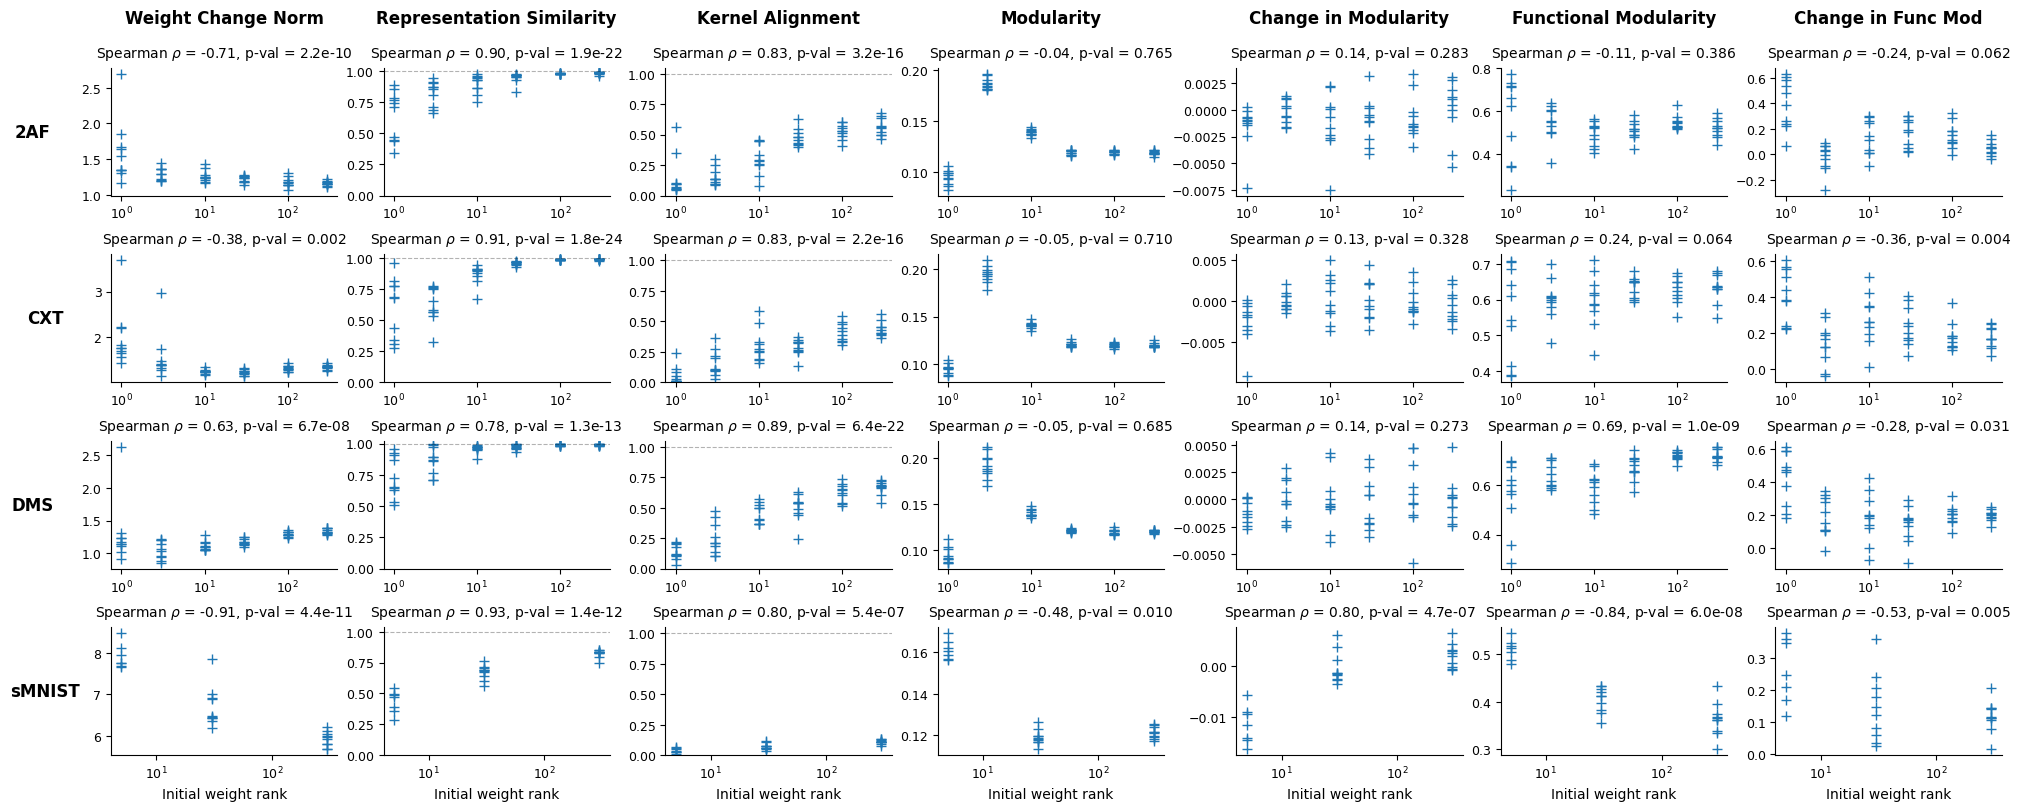

In [2]:
plot_metrics_with_stats('rr')

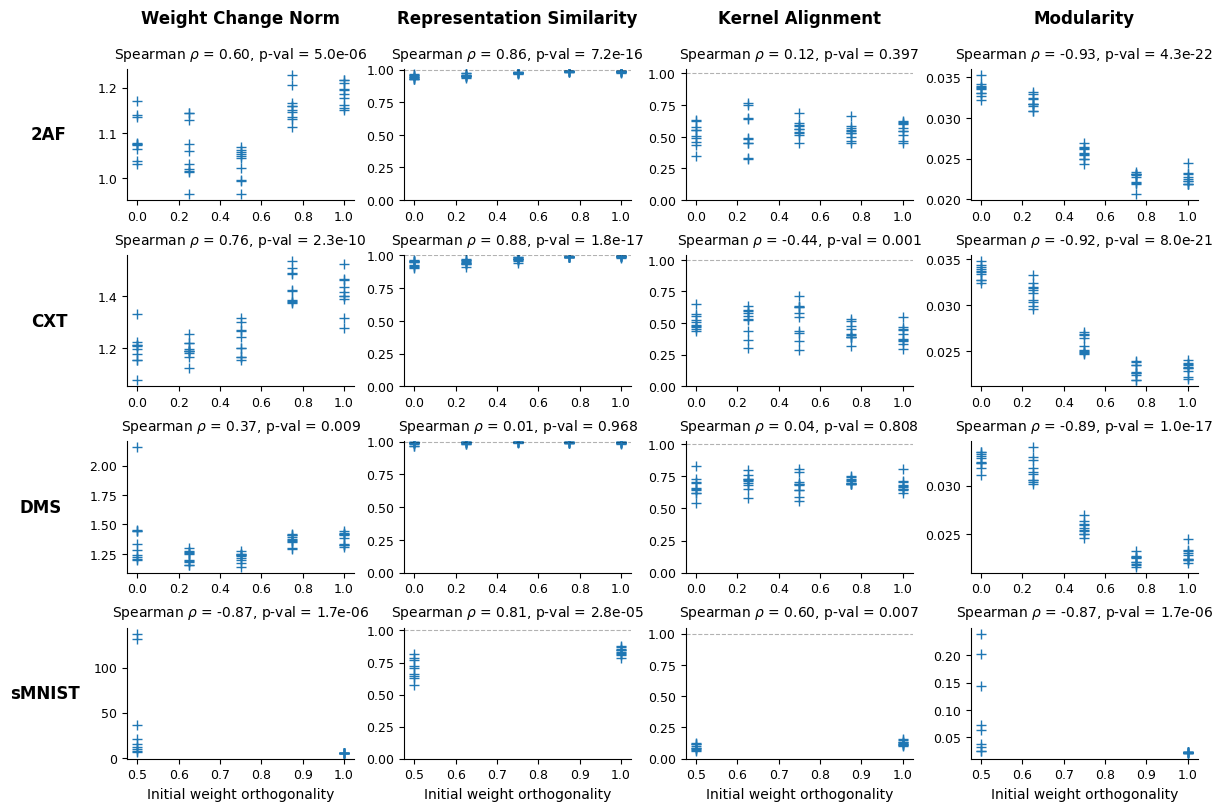

In [17]:
plot_metrics_with_stats('orthogonal')

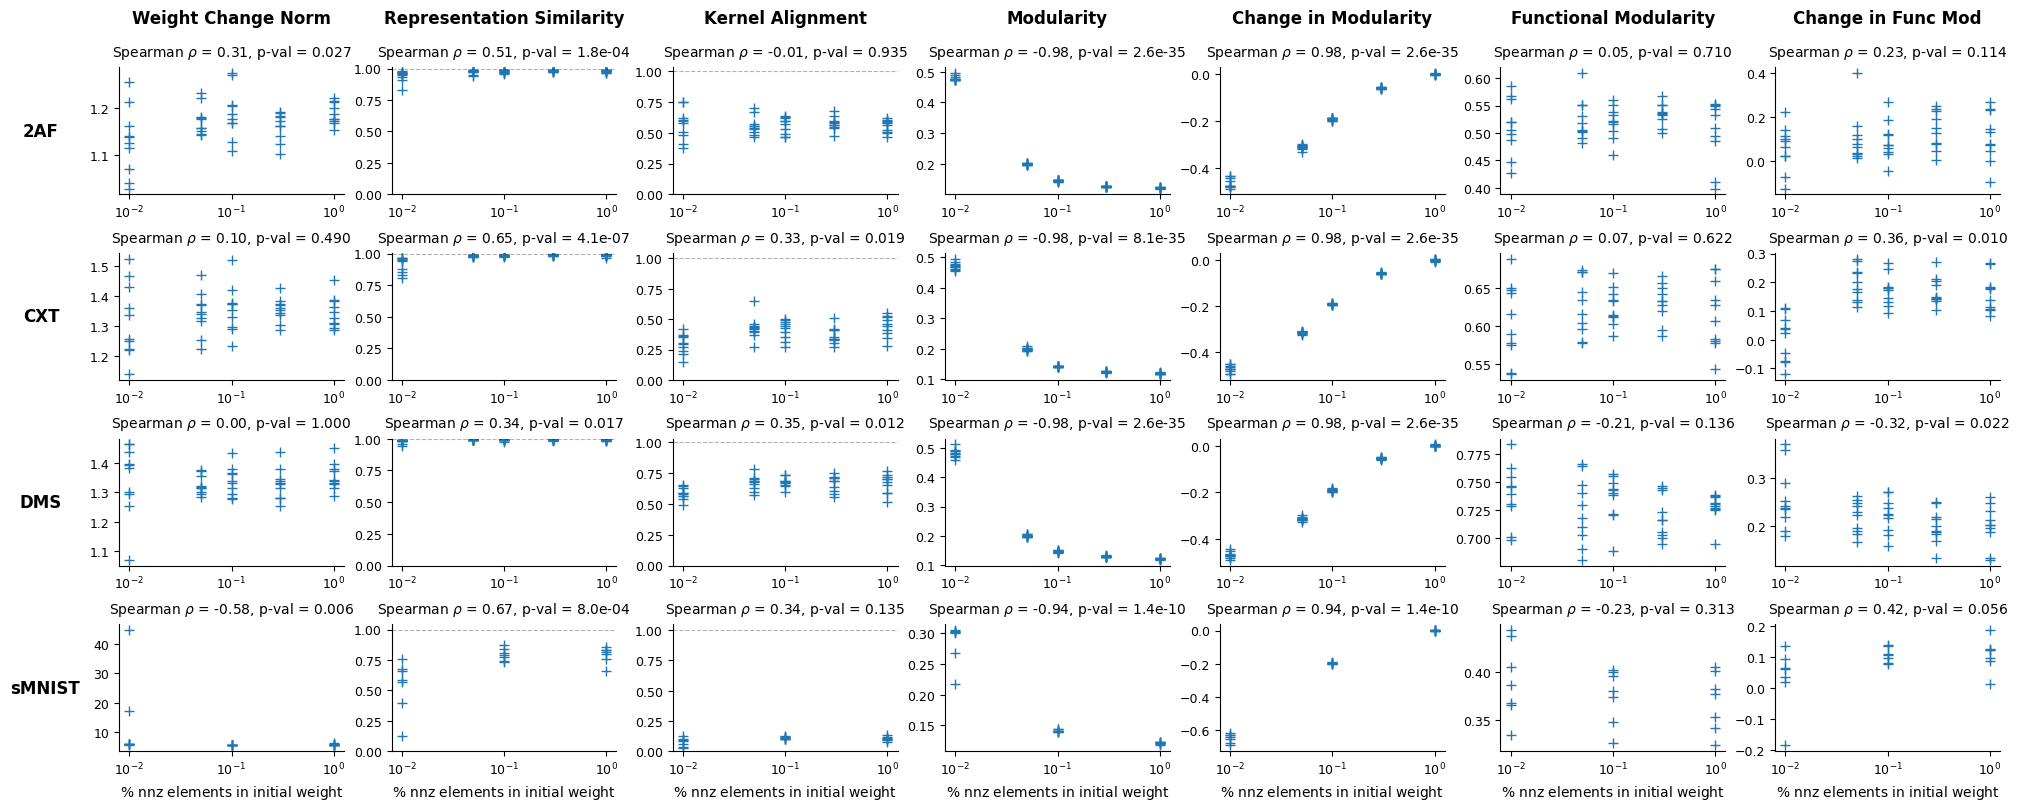

In [3]:
plot_metrics_with_stats('sparse')